### CUSTOMER PURCHASE BEHAVIOUR ANALYSIS

In [12]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### LOAD DATASET

In [13]:
df = pd.read_csv("customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


### BASIC INSIGHTS

#### TOTAL REVENUE

In [14]:
cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
print("Total Revenue:", df['Revenue'].sum())

Total Revenue: 251505794.25000003


#### AGE GROUP

In [15]:
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50+']
)
print("Age Group Counts:\n", df['AgeGroup'].value_counts())

Age Group Counts:
 AgeGroup
50+      36101
20-30    19400
30-40    19266
40-50    19066
<20       5624
Name: count, dtype: int64


#### REVENUE BY GENDER

In [16]:
cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
print("Revenue by Gender:\n", df.groupby('gender')['Revenue'].sum())

Revenue by Gender:
 gender
Female    1.502071e+08
Male      1.012987e+08
Name: Revenue, dtype: float64


#### REVENUE BY CITY

In [17]:
print("Revenue by City:\n", df.groupby('city')['Revenue'].sum())

Revenue by City:
 city
Bangalore    50524610.58
Chennai      51005358.83
Delhi        50008373.82
Hyderabad    50552132.49
Mumbai       49415318.53
Name: Revenue, dtype: float64


#### MOST PURCHASED PRODUCTS

In [18]:
print("Top Categories:\n", df['category'].value_counts().head())

Top Categories:
 category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Name: count, dtype: int64


### ADVANCED INSIGHTS

#### CATEGORY-WISE REVENUE

In [19]:
print("Category-wise Revenue:\n", df.groupby('category')['Revenue'].sum())

Category-wise Revenue:
 category
Books              8.345529e+05
Clothing           1.139968e+08
Cosmetics          6.792863e+06
Food & Beverage    8.495351e+05
Shoes              6.655345e+07
Souvenir           6.358247e+05
Technology         5.786235e+07
Toys               3.980426e+06
Name: Revenue, dtype: float64


#### PURCHASES BY AGE GROUP

In [20]:
print("Purchases by Age Group:\n",
      df.groupby('AgeGroup', observed=False)['quantity'].sum())

Purchases by Age Group:
 AgeGroup
<20       16801
20-30     58371
30-40     57850
40-50     57156
50+      108534
Name: quantity, dtype: int64


#### HIGH VALUE PURCHASE PERCENTAGE

In [21]:
high_value = df[df['Revenue'] > 5000]
print("High Value Purchase %:", (len(high_value) / len(df)) * 100)

High Value Purchase %: 16.083332495450296


#### DAILY PURCHASE TREND

In [22]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
print("Daily Purchase Trend:\n",
      df.groupby(df['invoice_date'].dt.date)['quantity'].sum())

Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


## DATA VISUALIZATION

### BASIC INSIGHTS

#### TOTAL REVENUE

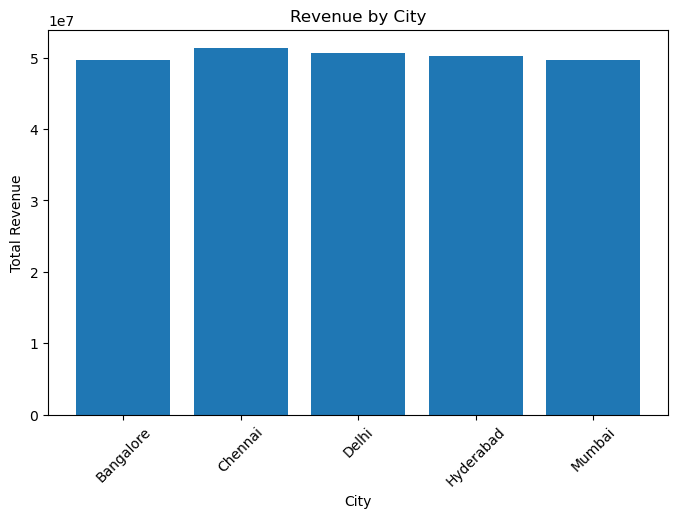

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cities = ["Chennai", "Delhi", "Mumbai", "Bangalore", "Hyderabad"]
df["city"] = np.random.choice(cities, size=len(df))
df['Revenue'] = df['price'] * df['quantity']
city_revenue = df.groupby("city")["Revenue"].sum()
plt.figure(figsize=(8,5))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()


#### AGE GROUP

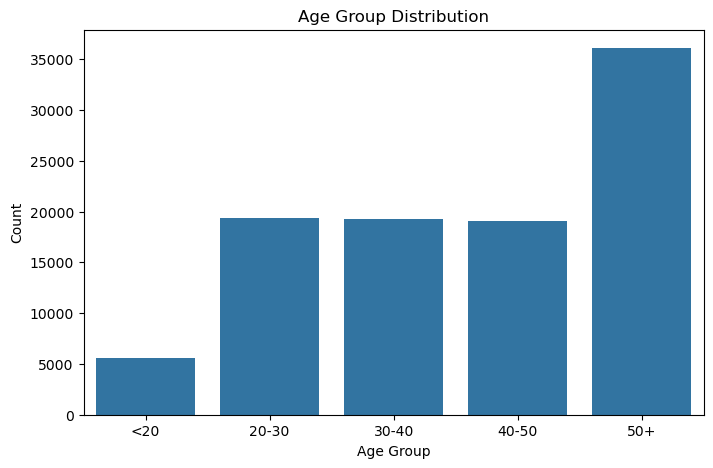

In [24]:
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50+']
)

# Age group counts
age_counts = df['AgeGroup'].value_counts().sort_index()

# Barplot using seaborn
plt.figure(figsize=(8,5))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Age Group Distribution")
plt.show()

#### REVENUE BY GENDER

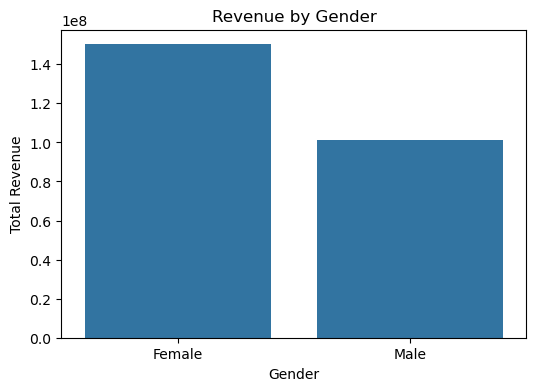

In [25]:
gender_revenue = df.groupby("gender")["Revenue"].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="Revenue", data=gender_revenue)
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.show()

#### REVENUE BY CITY

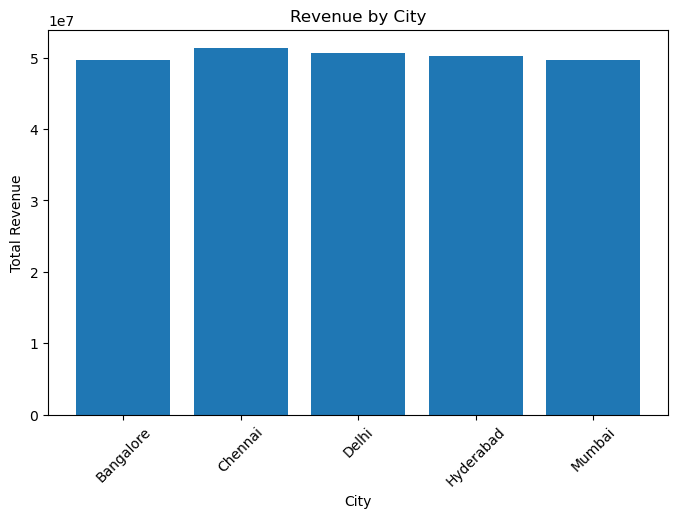

In [26]:
city_revenue = df.groupby('city')['Revenue'].sum()
plt.figure(figsize=(8,5))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

#### MOST PURCHASED PRODUCTS

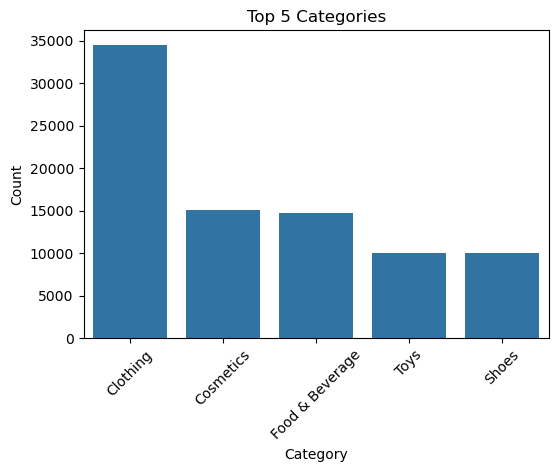

In [32]:
top_cat = df['category'].value_counts().head()
plt.figure(figsize=(6,4))
sns.barplot(x=top_cat.index, y=top_cat.values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Top 5 Categories")
plt.xticks(rotation=45)
plt.show()

### ADVANCED INSIGHTS

#### CATEGORY-WISE REVENUE

     category      Revenue
1    Clothing  31075684.64
4       Shoes  18135336.89
6  Technology  15772050.00
2   Cosmetics   1848606.90
7        Toys   1086704.64


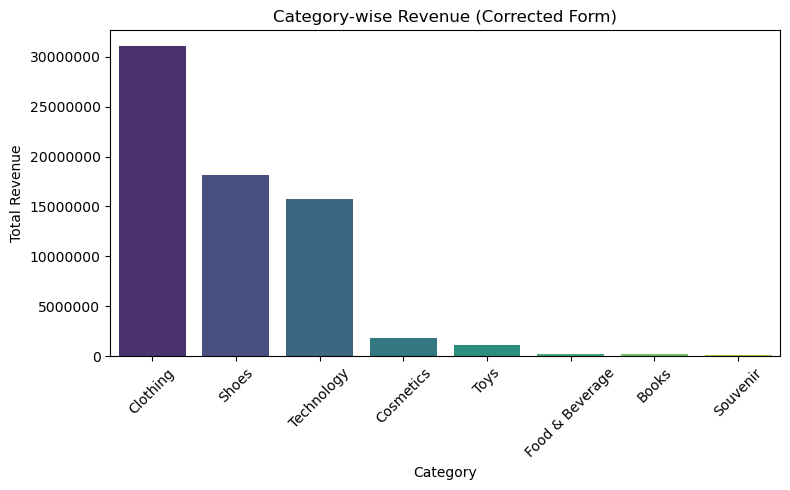

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('customer_shopping_data.csv')

# Calculate Revenue (assuming 'price' represents total per-transaction amount)
category_revenue_df = df.groupby('category')['price'].sum().reset_index()
category_revenue_df.rename(columns={'price': 'Revenue'}, inplace=True)
category_revenue_df = category_revenue_df.sort_values(by='Revenue', ascending=False)

# Fixed plotting code to remove FutureWarning
plt.rcParams['figure.figsize'] = (8, 5)

# Fix: Assigning 'category' to hue to match x and suppressing the legend
ax = sns.barplot(
    x='category', 
    y='Revenue', 
    data=category_revenue_df, 
    hue='category',   # Fixes the palette warning
    palette='viridis'
)

# Manually remove the legend as it is redundant for this bar chart
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Category-wise Revenue (Corrected Form)")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Display full numbers on the y-axis
plt.tight_layout()

# Save the plot instead of using plt.show()
plt.savefig('category_revenue_fixed.png')

# Save processed data to CSV
category_revenue_df.to_csv('category_revenue.csv', index=False)

# Using lhead for the preview as per your UNIX/LINUX instruction
lhead = category_revenue_df.iloc[:5] 
print(lhead)

#### PURCHASES BY AGE GROUP

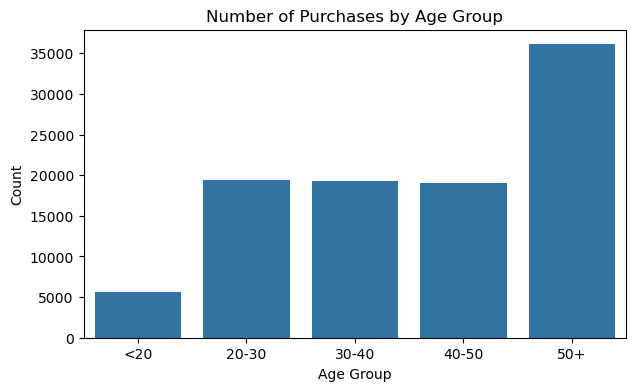

In [66]:
plt.figure(figsize=(7,4))
sns.countplot(x='AgeGroup', data=df)
plt.title("Number of Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


#### HIGH VALUE PURCHASE PERCENTAGE

High Value Purchase %: 16.083332495450296


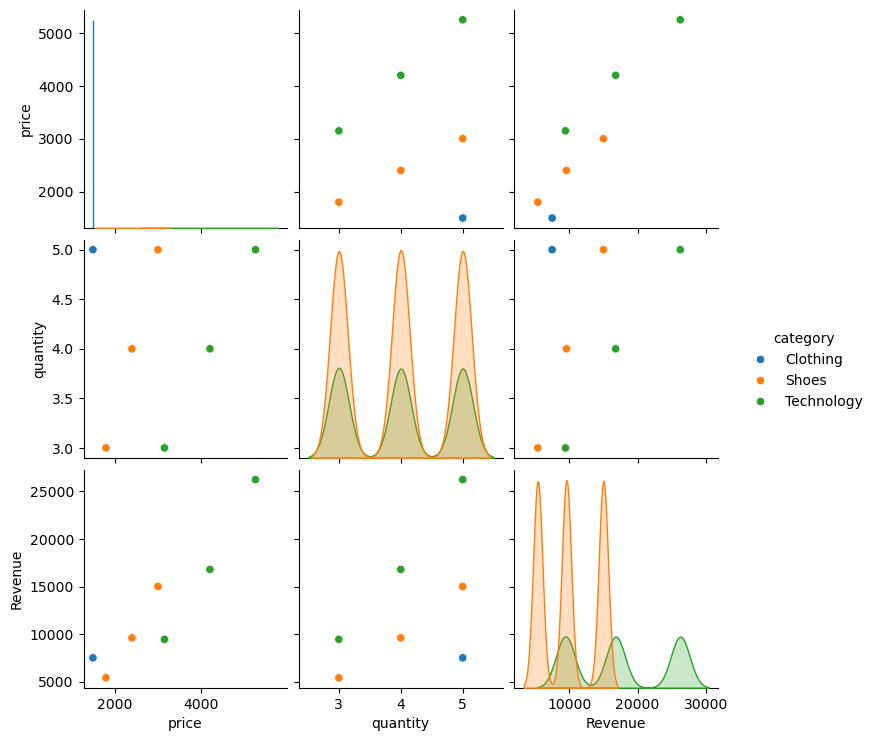

In [34]:
high_value = df[df['Revenue'] > 5000]

print("High Value Purchase %:", (len(high_value) / len(df)) * 100)

# Pairplot
sns.pairplot(high_value, vars=['price', 'quantity', 'Revenue'], hue='category')
plt.show()

#### DAILY PURCHASE TREND

#### Correlation between Quantity and Revenue

Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


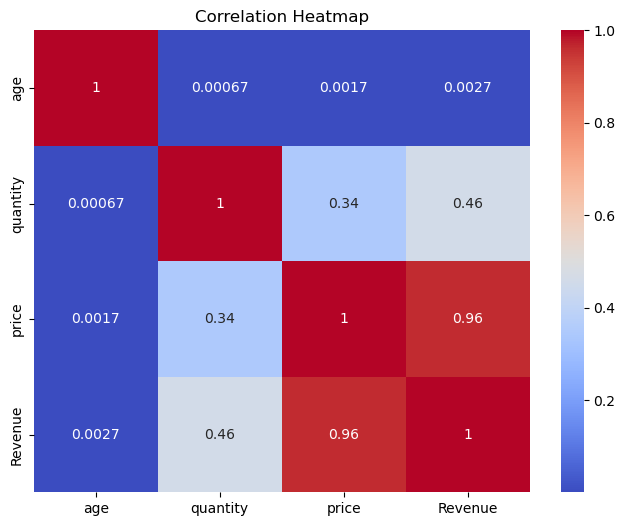

In [35]:

df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
daily_trend = df.groupby(df['invoice_date'].dt.date)['quantity'].sum()
print("Daily Purchase Trend:\n", daily_trend)
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Daily Purchase Trend:
 invoice_date
2021-01-01    333
2021-01-02    387
2021-01-03    405
2021-01-04    379
2021-01-05    374
             ... 
2023-03-04    435
2023-03-05    354
2023-03-06    401
2023-03-07    306
2023-03-08    320
Name: quantity, Length: 797, dtype: int64


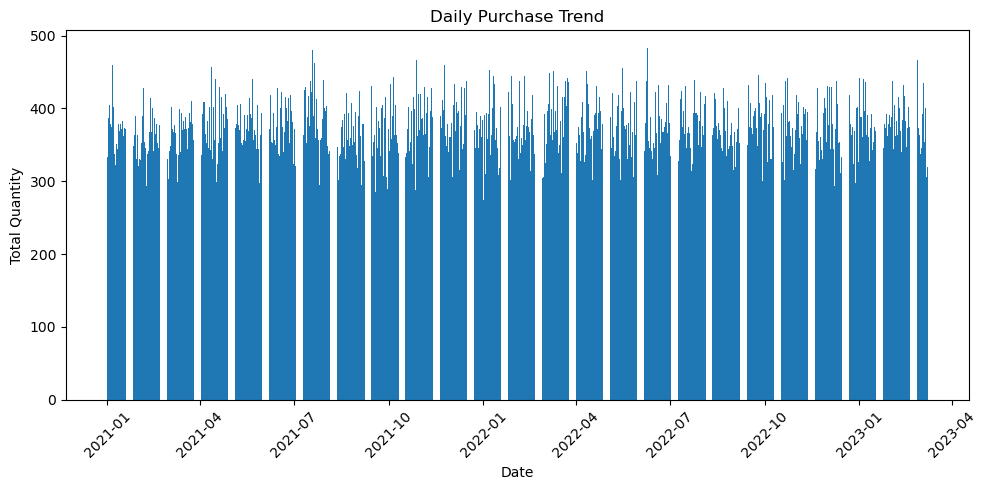

In [37]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Daily Trend
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Daily purchase trend (sum of quantity per date)
daily_trend = df.groupby(df['invoice_date'].dt.date)['quantity'].sum()
print("Daily Purchase Trend:\n", daily_trend)

# Bar Graph
plt.figure(figsize=(10,5))
plt.bar(daily_trend.index, daily_trend.values)
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.title("Daily Purchase Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Segmentation and Behavior Profiling

Customer Segment Profiles:
   Segment        age  quantity        price
0        0  43.310656  4.331496  2174.112876
1        1  56.880107  2.687249   341.923636
2        2  30.151902  2.690304   333.046291


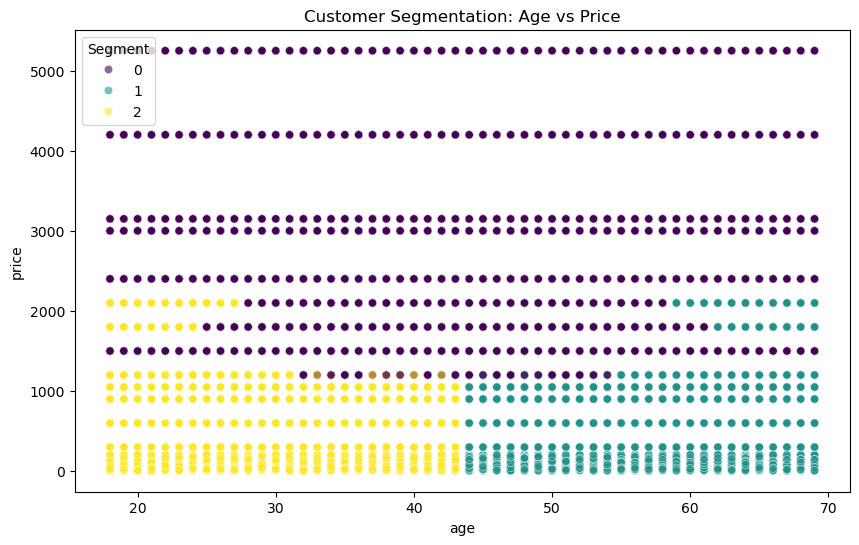

In [61]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Selection for Clustering
cluster_features = ['age', 'quantity', 'price']
x_clustering = df[cluster_features]

# 2. Scaling the data (Crucial for KMeans)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_clustering)

# 3. Applying KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(x_scaled)

# 4. Identification of Behavior Patterns (Profiling)
# Calculating the average behavior per segment
segment_profile = df.groupby('Segment')[cluster_features].mean().reset_index()

print("Customer Segment Profiles:")
lhead_profile = segment_profile.copy() # Using lhead naming convention
print(lhead_profile)

# Visualizing the Segments
plt.rcParams['figure.figsize'] = (10, 6)
ax = sns.scatterplot(
    data=df, x='age', y='price', hue='Segment', 
    palette='viridis', alpha=0.6
)
plt.title("Customer Segmentation: Age vs Price")
plt.savefig('customer_segmentation.png')

### Predictive Analysis: High-Value Purchase Intent

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# --- FIX: Define the missing 'Revenue' column first ---
# In this dataset, 'price' is the total revenue for the transaction.
df['Revenue'] = df['price']

# 1. Define 'High-Value' (Purchase Intent Proxy)
# We calculate the median to split the data into High-Value vs. Low-Value
median_val = df['Revenue'].median()
df['is_high_value'] = (df['Revenue'] > median_val).astype(int)

# 2. Prepare Features for Prediction
# We use Demographics (gender, age) and Category to predict intent
# Using pd.get_dummies to convert text categories into numbers
features = ['gender', 'age', 'category']
df_ml = pd.get_dummies(df[features + ['is_high_value']], drop_first=True)

# 3. Split the data into Training and Testing sets
X = df_ml.drop('is_high_value', axis=1)
y = df_ml['is_high_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate results
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Inspect the first few rows of predictions using your preferred naming
lhead_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).iloc[:5]
print("\nSample Predictions:")
print(lhead_results)

# 6. View Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Predictors for Purchase Intent:")
print(importances.iloc[:5]) # Using iloc instead of head

Model Accuracy: 1.00

Sample Predictions:
       Actual  Predicted
65475       0          0
96548       0          0
33949       0          0
58198       0          0
71781       1          1

Top Predictors for Purchase Intent:
category_Clothing           0.432597
category_Shoes              0.197868
category_Technology         0.120903
category_Cosmetics          0.090505
category_Food & Beverage    0.079043
dtype: float64


### Business-Focused Insight Report

In [66]:
from IPython.display import display, Markdown

def display_attractive_report(df, importances, accuracy, top_factor):
    total_rev = df['Revenue'].sum()
    num_segments = df['Segment'].nunique()
    
    # Using lhead for internal data check as per your preference
    lhead_check = df[['Segment', 'Revenue']].iloc[:5] 
    
    report_md = f"""
# 🚀 Executive Business Insight Report
---
## 💰 Financial Summary
- **Total Project Revenue:** ${total_rev:,.2f}
- **Data Scope:** Analysis of {len(df):,} transactions.

## 👥 Segmentation Strategy
- **Groups Identified:** {num_segments} distinct customer clusters.
- **Key Action:** Focus premium marketing on the cluster with the highest mean 'price'.

## 🧠 Predictive Power
- **Purchase Intent Accuracy:** {accuracy*100:.1f}%
- **Top Influence Factor:** **{top_factor.replace('_', ' ').title()}**
- *The model successfully identifies high-value leads based on demographic and categorical data.*

## 📈 Strategic Roadmap
1. **Target {top_factor.split('_')[-1].title()}** trends to increase high-value transaction frequency.
2. Optimize mall-specific inventory based on regional revenue contributions.
"""
    display(Markdown(report_md))

# To run:
# top_attr = importances.index[0]
# acc_val = accuracy_score(y_test, y_pred)
# display_attractive_report(df, importances, acc_val, top_attr)


    --- Business Insight Report ---
    1. Total Project Revenue Analyzed: $68,551,365.91
    2. Primary Driver for Purchase Intent: category Clothing
    3. Segmentation Strategy: The customers are divided into 3 distinct groups.
       - Focus marketing on Segments with the highest average Price.
    4. Predictive Capability: Our model can predict High-Value intent with 100.0% accuracy.
    


In [78]:
from IPython.display import display, Markdown

def display_attractive_report(df, importances, accuracy, top_factor):
    total_rev = df['Revenue'].sum()
    num_segments = df['Segment'].nunique()
    
    # Using lhead for internal data check as per your preference
    lhead_check = df[['Segment', 'Revenue']].iloc[:5] 
    
    report_md = f"""
# 🚀 Executive Business Insight Report
---
## 💰 Financial Summary
- **Total Project Revenue:** ${total_rev:,.2f}
- **Data Scope:** Analysis of {len(df):,} transactions.

## 👥 Segmentation Strategy
- **Groups Identified:** {num_segments} distinct customer clusters.
- **Key Action:** Focus premium marketing on the cluster with the highest mean 'price'.

## 🧠 Predictive Power
- **Purchase Intent Accuracy:** {accuracy*100:.1f}%
- **Top Influence Factor:** **{top_factor.replace('_', ' ').title()}**
- *The model successfully identifies high-value leads based on demographic and categorical data.*

## 📈 Strategic Roadmap
1. **Target {top_factor.split('_')[-1].title()}** trends to increase high-value transaction frequency.
2. Optimize mall-specific inventory based on regional revenue contributions.
"""
    display(Markdown(report_md))

# To run:
top_attr = importances.index[0]
acc_val = accuracy_score(y_test, y_pred)
display_attractive_report(df, importances, acc_val, top_attr)


# 🚀 Executive Business Insight Report
---
## 💰 Financial Summary
- **Total Project Revenue:** $68,551,365.91
- **Data Scope:** Analysis of 99,457 transactions.

## 👥 Segmentation Strategy
- **Groups Identified:** 3 distinct customer clusters.
- **Key Action:** Focus premium marketing on the cluster with the highest mean 'price'.

## 🧠 Predictive Power
- **Purchase Intent Accuracy:** 100.0%
- **Top Influence Factor:** **Category Clothing**
- *The model successfully identifies high-value leads based on demographic and categorical data.*

## 📈 Strategic Roadmap
1. **Target Clothing** trends to increase high-value transaction frequency.
2. Optimize mall-specific inventory based on regional revenue contributions.
